# Custom Dataset

In [1]:
!pip install torchmetrics
!pip install torchinfo

In [2]:
import torch
import torch.nn as nn
import requests
import zipfile
from pathlib import Path
import os
import torchvision
from torchvision.datasets import ImageFolder
from torchvision import transforms
import random
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchinfo import summary
import torchmetrics
from torchmetrics.classification import MulticlassAccuracy
from tqdm.auto import tqdm
import numpy as np
from PIL import Image
from torch.utils.data import Dataset
import glob

## Get Data

In [3]:
# Download data
data_folder = Path('data')
zip_path = data_folder / 'pizza_steak_sushi.zip'
if not data_folder.is_dir():
    data_folder.mkdir(parents=True, exist_ok=True)
    request = requests.get('https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip')
    with open(zip_path, 'wb') as f:
        f.write(request.content)
    
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(data_folder)

contents = os.listdir(data_folder)
print(contents)

print('\nTrain')
print(os.listdir(data_folder / 'train'))
print(os.listdir(data_folder / 'train' / 'sushi'))

print('\nTest')
print(os.listdir(data_folder / 'test'))
print(os.listdir(data_folder / 'test' / 'sushi'))

['train', 'test', 'pizza_steak_sushi.zip']

Train
['sushi', 'steak', 'pizza']
['3360232.jpg', '2674024.jpg', '1232045.jpg', '2021381.jpg', '2641778.jpg', '170385.jpg', '1551817.jpg', '765684.jpg', '3353428.jpg', '1571146.jpg', '121940.jpg', '2492146.jpg', '2813454.jpg', '843815.jpg', '2873571.jpg', '1575445.jpg', '2017378.jpg', '390178.jpg', '2175561.jpg', '700405.jpg', '2021685.jpg', '3107839.jpg', '686426.jpg', '710379.jpg', '307738.jpg', '542188.jpg', '17704.jpg', '929471.jpg', '148799.jpg', '3251688.jpg', '3426958.jpg', '93139.jpg', '3737197.jpg', '1552504.jpg', '1209865.jpg', '2323548.jpg', '1280119.jpg', '1957449.jpg', '1070104.jpg', '2574453.jpg', '1615453.jpg', '2120573.jpg', '1129338.jpg', '2871052.jpg', '773725.jpg', '268990.jpg', '2019344.jpg', '385154.jpg', '821108.jpg', '2590819.jpg', '497686.jpg', '377047.jpg', '1214108.jpg', '14046.jpg', '3360207.jpg', '794647.jpg', '200025.jpg', '2720223.jpg', '3081701.jpg', '748830.jpg', '2797464.jpg', '1138695.jpg', '2004525.jpg', '35

## Create Custom Image Folder

In [4]:
# Testing functions that are required

all_train_imgs_path = glob.glob('data/train/*/*.jpg')
random_img_path = random.choice(all_train_imgs_path)

img_array = np.array(Image.open(random_img_path))
print('Image shape: ', img_array.shape)
print(f'Image values: {np.min(img_array)} to {np.max(img_array)}')

Image shape:  (512, 512, 3)
Image values: 0 to 255


In [5]:
class CustomImageFolder(Dataset):
    def __init__(
            self,
            transform: torchvision.transforms,
            data_path: str
    ):
        super().__init__()
        self.transform = transform
        self.img_paths = glob.glob(data_path + '/*/*.jpg')
        self.classes = sorted(os.listdir(Path(data_path)))
        self.classes_to_idx = {item: idx for idx, item in enumerate(self.classes)}
    
    def load_image(self, idx:int):
        return Image.open(self.img_paths[idx])
    
    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx:int):
        img_path = self.img_paths[idx]
        img_class = Path(img_path).parent.stem
        img_label = self.classes_to_idx[img_class]

        image = self.load_image(idx)
        if self.transform:
            image = self.transform(image)
            return (image, img_label)
        else:
            return (image,img_label)

## Create Dataset

In [6]:
simple_train_transform = transforms.Compose([
    # Convert into tensors
    transforms.Resize((256, 256)), # Resize
    transforms.TrivialAugmentWide(),
    transforms.ToTensor() # From PIL Image / numpt ndarray in [0, 255] and HxWxC to Tensor in [0.0, 1.0] and CxHxW
])

simple_test_transform = transforms.Compose([
    # Convert into tensors
    transforms.Resize((256, 256)), # Resize
    transforms.ToTensor() # From PIL Image / numpt ndarray in [0, 255] and HxWxC to Tensor in [0.0, 1.0] and CxHxW
])

train_data = CustomImageFolder(
    transform = simple_train_transform,
    data_path = str(data_folder / 'train')
)

test_data = CustomImageFolder(
    transform = simple_test_transform,
    data_path = str(data_folder / 'test')
)


## Visualize Dataset

Length of the training dataset:  225
Size of an image:  torch.Size([3, 256, 256])
Value of an image: 0.01568627543747425 to 0.9882352948188782
Class Dictionary:  {'pizza': 0, 'steak': 1, 'sushi': 2}


(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

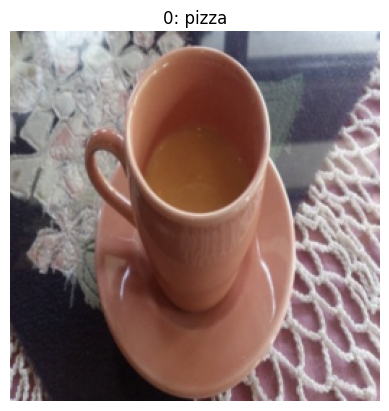

In [7]:
# Visualize Dataset

random_idx = random.randint(0, len(train_data)-1)

image, label = train_data[random_idx]
print('Length of the training dataset: ', len(train_data))
print('Size of an image: ', image.shape)
print(f'Value of an image: {torch.min(image)} to {torch.max(image)}')
print('Class Dictionary: ', train_data.classes_to_idx)

plt.imshow(image.permute(1, 2, 0))
plt.title(f'{label}: {train_data.classes[label]}')
plt.axis('off')




## Create Dataloader

In [8]:
BATCH_SIZE = 32

train_dataloader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_dataloader = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=True
)

## Visualize dataloader

In [9]:
image_batch, label_batch = next(iter(train_dataloader))

print('Batch size: ', len(image_batch))
print('Size of an image batch: ', image_batch.shape)
print('Size of a label batch: ', label_batch.shape)

Batch size:  32
Size of an image batch:  torch.Size([32, 3, 256, 256])
Size of a label batch:  torch.Size([32])


## Create a model

In [10]:
class TinyVGG(nn.Module):
    def __init__(
            self,
            in_channels: int,
            hidden_units: int,
            out_channels: int,
            in_img_size: int
        ):
        super().__init__()

        self.conv_layer_1 = nn.Sequential(
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(
                kernel_size=2
            )
        )

        self.conv_layer_2 = nn.Sequential(
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(
                kernel_size=2
            )
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(
                in_features=hidden_units*int(in_img_size/4)*int(in_img_size/4),
                out_features=1024
            ),
            nn.ReLU(),
            nn.Linear(
                in_features=1024,
                out_features=512
            ),
            nn.ReLU(),
            nn.Linear(
                in_features=512,
                out_features=256
            ),
            nn.ReLU(),
            nn.Linear(
                in_features=256,
                out_features=out_channels
            )
        )
    
    def forward(self, x:torch.Tensor) -> torch.Tensor:
        return self.classifier(self.conv_layer_2(self.conv_layer_1(x)))



## Visualize Model

In [11]:
model = TinyVGG(3, 32, 3, 64)
summary(model, input_size=(1,3,64,64))

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 3]                    --
├─Sequential: 1-1                        [1, 32, 32, 32]           --
│    └─Conv2d: 2-1                       [1, 32, 64, 64]           896
│    └─ReLU: 2-2                         [1, 32, 64, 64]           --
│    └─Conv2d: 2-3                       [1, 32, 64, 64]           9,248
│    └─ReLU: 2-4                         [1, 32, 64, 64]           --
│    └─MaxPool2d: 2-5                    [1, 32, 32, 32]           --
├─Sequential: 1-2                        [1, 32, 16, 16]           --
│    └─Conv2d: 2-6                       [1, 32, 32, 32]           9,248
│    └─ReLU: 2-7                         [1, 32, 32, 32]           --
│    └─Conv2d: 2-8                       [1, 32, 32, 32]           9,248
│    └─ReLU: 2-9                         [1, 32, 32, 32]           --
│    └─MaxPool2d: 2-10                   [1, 32, 16, 16]           --
├─Seq

## Training and Testing Step

In [12]:
def train_step(
        model: nn.Module,
        data: torch.Tensor,
        label: torch.Tensor,
        loss_fn: nn.Module,
        acc_fn: torchmetrics.classification,
        optimizer: torch.optim,
        num_classes: int
) -> tuple[float, float]:
    
    model.train()
    y_preds = model(data)
    loss = loss_fn(y_preds.squeeze(), torch.nn.functional.one_hot(label, num_classes=num_classes).to(torch.float32).squeeze())
    acc = acc_fn(torch.argmax(y_preds, dim=1), label)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item(), acc.item()

def test_step(
        model: nn.Module,
        data: torch.Tensor,
        label: torch.Tensor,
        loss_fn: nn.Module,
        acc_fn: torchmetrics.classification,
        num_classes: int
) -> tuple[float, float]:
    
    model.eval()
    with torch.inference_mode():
        y_preds = model(data).squeeze()
        loss = loss_fn(y_preds.squeeze(), torch.nn.functional.one_hot(label, num_classes=num_classes).to(torch.float32).squeeze())
        acc = acc_fn(torch.argmax(y_preds, dim=1), label)

    return loss.item(), acc.item()




## Train / Testing Loop

In [13]:
# Hyperparameter
device = 'cuda' if torch.cuda.is_available() else 'cpu'
NUM_CLASSES = len(train_data.classes)
EPOCHS = 100
LEARNING_RATE = 1E-5

# Model and utils
model_0 = TinyVGG(
    in_channels = 3,
    hidden_units= 32,
    out_channels = NUM_CLASSES,
    in_img_size = train_data[0][0].shape[-1]
).to(device)

optimizer = torch.optim.Adam(
    model_0.parameters(),
    LEARNING_RATE
)

loss_fn = torch.nn.CrossEntropyLoss()

acc_fn = MulticlassAccuracy(
    num_classes=NUM_CLASSES,
    average='micro'
).to(device)

# Train / Test Loop
plt_epochs = []
plt_train_losses = []
plt_train_accs = []
plt_test_losses = []
plt_test_accs = []

for epoch in range(EPOCHS):

    train_loss = 0
    train_acc = 0
    test_loss = 0
    test_acc = 0

    for X, y in tqdm(train_dataloader):
        loss, acc = train_step(
            model=model_0,
            data=X.to(device),
            label=y.to(device),
            loss_fn=loss_fn,
            acc_fn=acc_fn,
            optimizer=optimizer,
            num_classes=NUM_CLASSES
        )
        train_loss += loss
        train_acc += acc
    
    for X, y in tqdm(test_dataloader):
        loss, acc = test_step(
            model=model_0,
            data=X.to(device),
            label=y.to(device),
            loss_fn=loss_fn,
            acc_fn=acc_fn,
            num_classes=NUM_CLASSES
        )
        test_loss += loss
        test_acc += acc
    
    train_batches = len(train_dataloader)
    test_batches = len(test_dataloader)
    train_loss /= train_batches
    train_acc /= train_batches
    test_loss /= test_batches
    test_acc /= test_batches

    plt_epochs.append(epoch)
    plt_train_losses.append(train_loss)
    plt_train_accs.append(train_acc)
    plt_test_losses.append(test_loss)
    plt_test_accs.append(test_acc)

    print('Epoch: ', epoch)
    print(f'Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.2f}')
    print(f'Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.2f}')



  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch:  0
Train Loss: 1.1003 | Train Accuracy: 0.27
Test Loss: 1.0999 | Test Accuracy: 0.38


  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

...

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch:  98
Train Loss: 0.7431 | Train Accuracy: 0.71
Test Loss: 0.9784 | Test Accuracy: 0.52


  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch:  99
Train Loss: 0.8420 | Train Accuracy: 0.57
Test Loss: 0.9381 | Test Accuracy: 0.57


## Visualize results

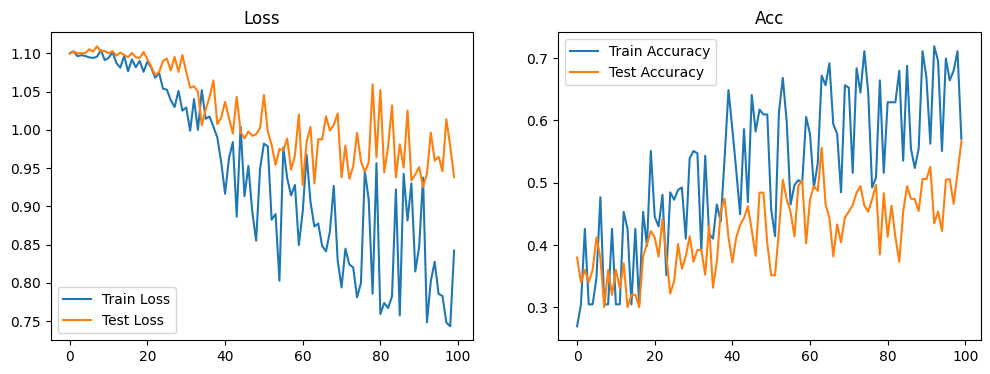

In [14]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.title('Loss')
plt.plot(plt_epochs, plt_train_losses, label='Train Loss')
plt.plot(plt_epochs, plt_test_losses, label='Test Loss')
plt.legend()

plt.subplot(1,2,2)
plt.title('Acc')
plt.plot(plt_epochs, plt_train_accs, label='Train Accuracy')
plt.plot(plt_epochs, plt_test_accs, label='Test Accuracy')
plt.legend()

## Save and Load models

In [15]:
save_folder = Path('models')
save_folder.mkdir(parents=True, exist_ok=True)
save_path = save_folder / 'model_0.pt'
torch.save(model_0.state_dict(), save_path)
    

In [16]:
loaded_model = TinyVGG(
    in_channels=3,
    hidden_units=32,
    out_channels=NUM_CLASSES,
    in_img_size=train_data[0][0].shape[-1]
).to(device)

loaded_model.load_state_dict(torch.load(save_path))


<All keys matched successfully>

## Random Testing on images

Text(0.5, 1.0, 'GT: steak | Pred: sushi | Probs: 0.44')

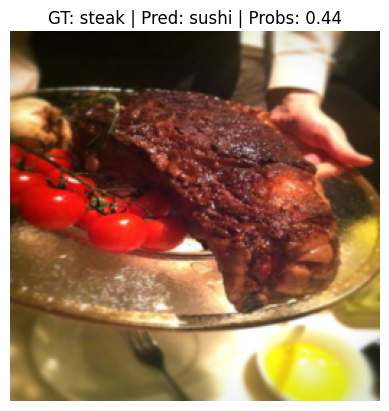

In [22]:
all_test_img_paths = glob.glob('data/test/*/*.jpg')

# tensor, 0 to 1
random_test_img_path = random.choice(all_test_img_paths)
random_test_img = simple_test_transform(Image.open(random_test_img_path)).to(device).unsqueeze(dim=0)
random_test_img_class = Path(random_test_img_path).parent.stem

loaded_model.eval()
with torch.inference_mode():
    y_preds = loaded_model(random_test_img).squeeze()
    y_probs = torch.softmax(y_preds, dim=0)
    y_pred_labels = torch.argmax(y_probs)

plt.imshow(random_test_img.squeeze().permute(1,2,0).cpu())
plt.axis('off')
plt.title(f'GT: {random_test_img_class} | Pred: {train_data.classes[y_pred_labels]} | Probs: {y_probs[y_pred_labels]:.2f}')